In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from testgen.analysis_utils import *

In [2]:
# read results file
base_path = Path().cwd()
results_path = base_path / "results"
data_path = base_path / "data"

In [3]:
sensors_df = pd.read_excel(data_path / "sensor_requirements.xlsx")
actuators_df = pd.read_excel(data_path / "actuator_requirements.xlsx")
actuators_df.columns = ["requirement"]

In [4]:
labels = get_sensors_labels()
labels

{'acceleration_pedal': 'Acc',
 'wheel_steering_angle': 'WSA',
 'wheel_speed': 'WS',
 'yaw_rate': 'YR',
 'steering_torque': 'ST'}

In [5]:
sensors_df_t = sensors_df[["requirement"]].copy()
sensors_df_t.insert(1, "is_actuator", 0)

actuators_df_t = actuators_df[["requirement"]].copy()
actuators_df_t.insert(1, "is_actuator", 1)

df = pd.concat([actuators_df_t, sensors_df_t])

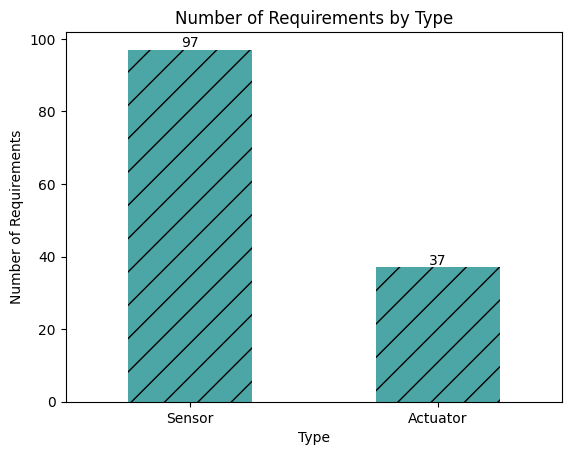

In [6]:
ax = df["is_actuator"].value_counts().plot(kind="bar", color="teal", alpha=0.7, hatch="/")
_ = ax.bar_label(ax.containers[0])

ax.set_xticklabels(["Sensor", "Actuator"], rotation=0)
ax.set_ylabel("Number of Requirements")
ax.set_xlabel("Type")
ax.set_title("Number of Requirements by Type")

plt.savefig("figures/requirements_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

# Actuator vs Sensor

In [9]:
actuator_available_results, actuator_results_single = get_best_results(
    results_path, "sensor-actuator*.json"
)

In [10]:
actuator_stats_df, actuator_responses_df = result_to_actuator_df(actuator_available_results)
actuator_stats_df["accuracy"] = (actuator_stats_df["accuracy"] *100).round(1)

In [11]:
# table outlining the accuracy of each model and number of examples
actuator_stats_df_latex = actuator_stats_df.copy().sort_values(by=["accuracy"], ascending=False)
actuator_stats_df_latex = actuator_stats_df_latex.reset_index(drop=True)
actuator_stats_df_latex = actuator_stats_df_latex.rename(
    columns={
        "model": "Model",
        "accuracy": "Accuracy (%)",
        "number_of_examples": "Number of Examples"
    }
)
actuator_stats_df_latex = actuator_stats_df_latex[["Model", "Accuracy (%)", "Number of Examples"]]

actuator_stats_df_latex = actuator_stats_df_latex.pivot(
    index="Model", columns="Number of Examples", values="Accuracy (%)"
)

actuator_stats_df_latex.to_latex(
    "tables/actuator_stats.tex",
    index=True,
    multicolumn=True,
    position="centering",
    float_format="%.1f",
    column_format="lccc",
    escape=True,
    caption="Actuator vs Sensor Model Statistics",
    label="tab:actuator_stats",
)

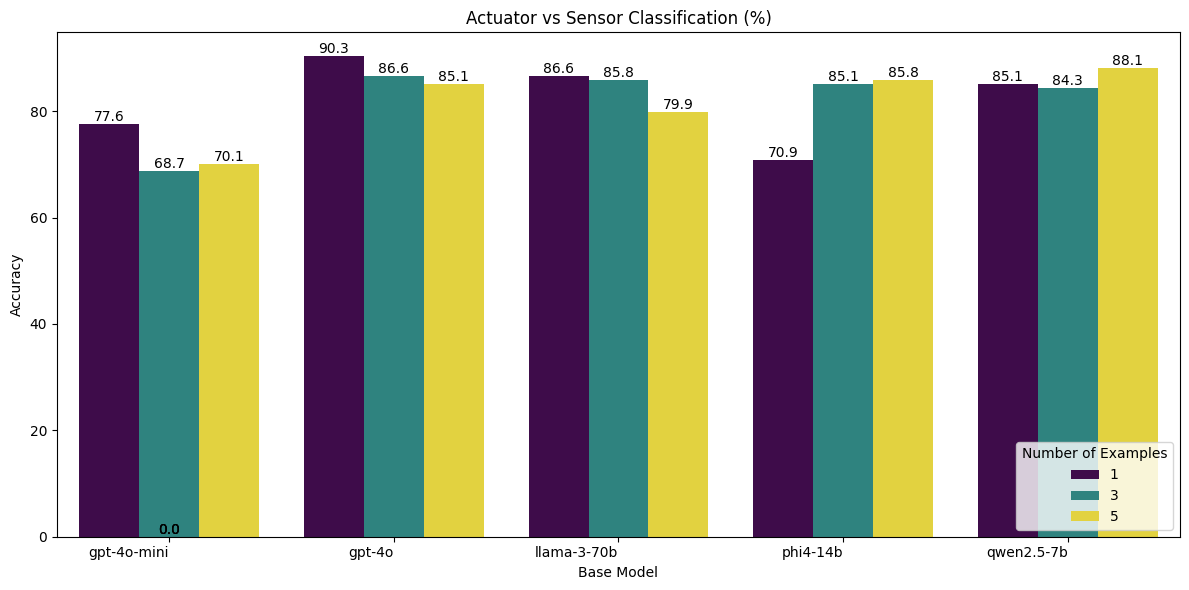

In [12]:
# Create the grouped bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
ax = sns.barplot(
    x="model",
    y="accuracy",
    hue="number_of_examples",
    data=actuator_stats_df,
    palette="viridis",
)

# Add data labels
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".1f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
    )

# Add title and labels
plt.title("Actuator vs Sensor Classification (%)")
plt.xlabel("Base Model")
plt.ylabel("Accuracy")

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0, ha="right")

# fix legend in lower right corner
plt.legend(
    title="Number of Examples",
    loc="lower right",
    fontsize=10,
    title_fontsize=10,
)

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# Single Analysis

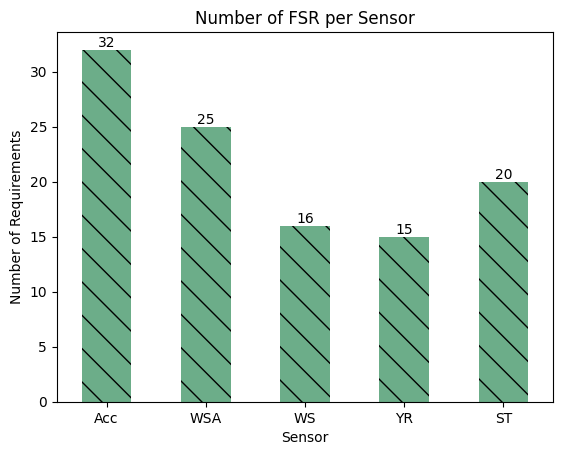

In [13]:
sensors_df_t = sensors_df.copy().rename(columns=labels)
ax = sensors_df_t.sum(numeric_only=True).plot(kind="bar", color="seagreen", alpha=0.7, hatch="\\")
_ = ax.bar_label(ax.containers[0])

ax.set_ylabel("Number of Requirements")
ax.set_xlabel("Sensor")
ax.set_title("Number of FSR per Sensor")

plt.xticks(rotation=0)
plt.savefig("figures/requirements_by_sensor.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
single_available_results, single_results_single = get_best_results(
    results_path, "sensor_single*.json"
)

In [15]:
single_stats_df, single_responses_df, single_mismatch_stats_df = result_to_sensor_df(single_available_results)
single_stats_df["accuracy"] = (single_stats_df["accuracy"] *100).round(1)

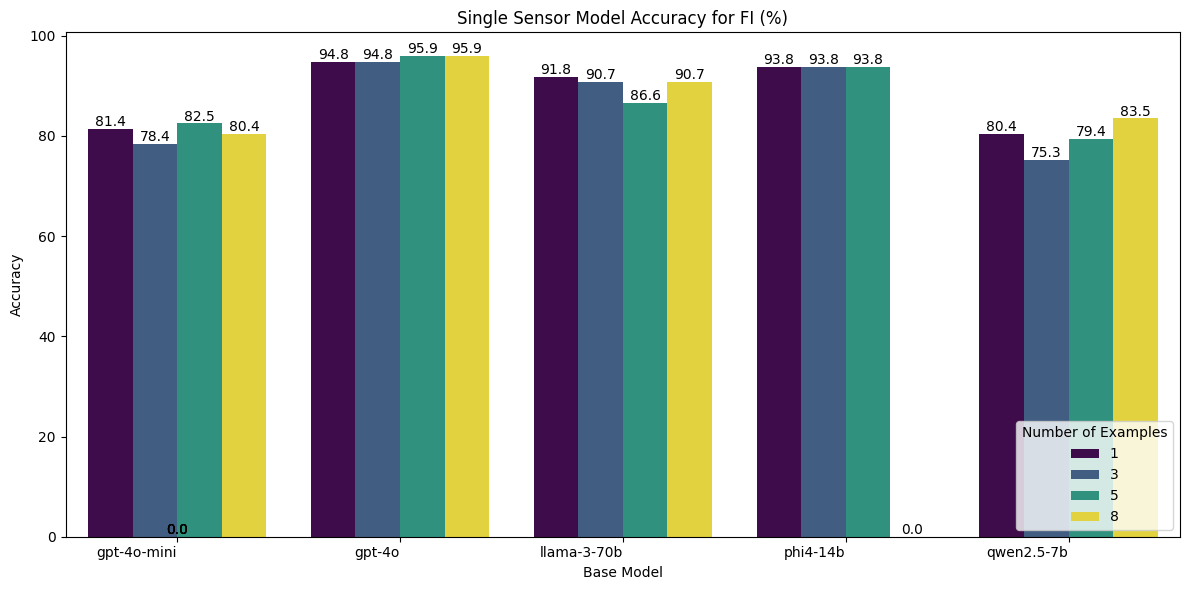

In [16]:
# Create the grouped bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
ax = sns.barplot(
    x="model", y="accuracy", hue="number_of_examples", data=single_stats_df, palette="viridis"
)

# Add data labels
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".1f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
    )

# Add title and labels
plt.title("Single Sensor Model Accuracy for FI (%)")
plt.xlabel("Base Model")
plt.ylabel("Accuracy")

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0, ha="right")

# fix legend in lower right corner
plt.legend(
    title="Number of Examples",
    loc="lower right",
    fontsize=10,
    title_fontsize=10,
)

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [17]:
# table outlining the accuracy of each model and number of examples
single_stats_df_latex = single_stats_df.copy().sort_values(by=["accuracy"], ascending=False)
single_stats_df_latex = single_stats_df_latex.reset_index(drop=True)
single_stats_df_latex = single_stats_df_latex.rename(
    columns={
        "model": "Model",
        "accuracy": "Accuracy (%)",
        "number_of_examples": "Number of Examples"
    }
)
single_stats_df_latex = single_stats_df_latex[["Model", "Accuracy (%)", "Number of Examples"]]

single_stats_df_latex = single_stats_df_latex.pivot(
    index="Model", columns="Number of Examples", values="Accuracy (%)"
)

single_stats_df_latex.to_latex(
    "tables/single_stats.tex",
    index=True,
    multicolumn=False,
    float_format="%.1f",
    column_format="lccc",
    escape=True,
    caption="Single Sensor Model Accuracy (%)",
    label="tab:single_stats",
)

In [18]:
# # Create the grouped bar plot using Seaborn
# plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
# ax = sns.barplot(
#     x="model",
#     y="total_tokens",
#     hue="number_of_examples",
#     data=stats_df,
#     palette="viridis",
# )

# # Add data labels
# for p in ax.patches:
#     ax.annotate(
#         format(p.get_height(), ",.0f"),
#         (p.get_x() + p.get_width() / 2.0, p.get_height()),
#         ha="center",
#         va="center",
#         xytext=(0, 5),
#         textcoords="offset points",
#         fontsize=10,
#     )

# # Add title and labels
# plt.title("Single Sensor Model Total Token Usage for FI")
# plt.xlabel("Base Model")
# plt.ylabel("Accuracy")

# # Rotate x-axis labels for better readability if needed
# plt.xticks(rotation=0, ha="right")

# # fix legend in lower right corner
# plt.legend(
#     title="Number of Examples",
#     loc="lower right",
#     fontsize=10,
#     title_fontsize=10,
# )

# # Display the plot
# plt.tight_layout()  # Adjust layout to prevent labels from overlapping
# plt.show()

In [19]:
def replace_and_join(values, labels):
    return " & ".join([labels.get(value) for value in values])


single_responses_df["pred_target_sensor_str"] = single_responses_df["pred_target_sensor"].apply(
    lambda x: replace_and_join(x, labels)
)
single_responses_df["true_target_sensor_str"] = single_responses_df["true_target_sensor"].apply(
    lambda x: replace_and_join(x, labels)
)

In [20]:
scores_df = calc_scores(single_responses_df)

scores_df

,model,number_of_examples,accuracy,precision,recall,f1
sensor,,,,,,
All,gpt-4o-mini,1,0.81,0.83,0.98,0.89
Acc,gpt-4o-mini,1,1.00,1.00,1.00,1.00
Acc & WSA,gpt-4o-mini,1,0.92,1.00,0.92,0.96
ST,gpt-4o-mini,1,1.00,1.00,1.00,1.00
WS,gpt-4o-mini,1,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...
Acc & WSA,qwen2.5-7b,8,0.88,1.00,0.88,0.93
ST,qwen2.5-7b,8,1.00,1.00,1.00,1.00
WS,qwen2.5-7b,8,1.00,1.00,1.00,1.00


# Batch Analysis

In [43]:
batch_available_results, batch_results_single = get_best_results(
    results_path, "sensor_bulk*.json"
)

In [44]:
batch_stats_df, batch_responses_df, batch_mismatch_stats_df = result_to_sensor_df(batch_available_results)
batch_stats_df["accuracy"] = (batch_stats_df["accuracy"] *100).round(1)

In [ ]:
# table outlining the accuracy of each model and number of examples
for bs in batch_stats_df["batch_size"].unique():

    batch_stats_df_latex = batch_stats_df.loc[batch_stats_df["batch_size"] == bs].copy()
    batch_stats_df_latex = batch_stats_df_latex.rename(
        columns={
            "model": "Model",
            "accuracy": "Accuracy (%)",
            "number_of_examples": "Number of Examples",
        }
    )
    batch_stats_df_latex = batch_stats_df_latex[["Model", "Accuracy (%)", "Number of Examples"]]

    batch_stats_df_latex = batch_stats_df_latex.pivot(
        index="Model", columns="Number of Examples", values="Accuracy (%)"
    )

    batch_stats_df_latex.to_latex(
        f"tables/batch_{bs}_stats.tex",
        index=True,
        multicolumn=False,
        float_format="%.1f",
        column_format="lccc",
        escape=True,
        label=f"tab:batch_{bs}_stats",
    )

# Dropped Analysis

In [76]:
dropped_available_results, dropped_results_single = get_best_results(
    results_path, "sensor_dropped*.json"
)

In [77]:
dropped_stats_df, dropped_responses_df, dropped_mismatch_stats_df = result_to_sensor_df(dropped_available_results)
dropped_stats_df["accuracy"] = (dropped_stats_df["accuracy"] *100).round(1)

In [79]:
# table outlining the accuracy of each model and number of examples
dropped_stats_df_latex = dropped_stats_df.copy()
dropped_stats_df_latex = dropped_stats_df_latex.rename(
    columns={
        "model": "Model",
        "accuracy": "Accuracy (%)",
        "number_of_examples": "Number of Examples"
    }
)
dropped_stats_df_latex = dropped_stats_df_latex[["Model", "Accuracy (%)", "Number of Examples"]]

dropped_stats_df_latex = dropped_stats_df_latex.pivot(
    index="Model", columns="Number of Examples", values="Accuracy (%)"
)

dropped_stats_df_latex.to_latex(
    "tables/dropped_stats.tex",
    index=True,
    multicolumn=False,
    float_format="%.1f",
    column_format="lcccc",
    escape=True,
    caption="Dropped Sensor (Single) Model Accuracy (%)",
    label="tab:dropped_stats",
)